In [36]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

Task 1: Data Understanding and Visualization:

Training set: (90, 128, 128, 3), Labels: (90,)
Testing set: (30, 128, 128, 3), Labels: (30,)


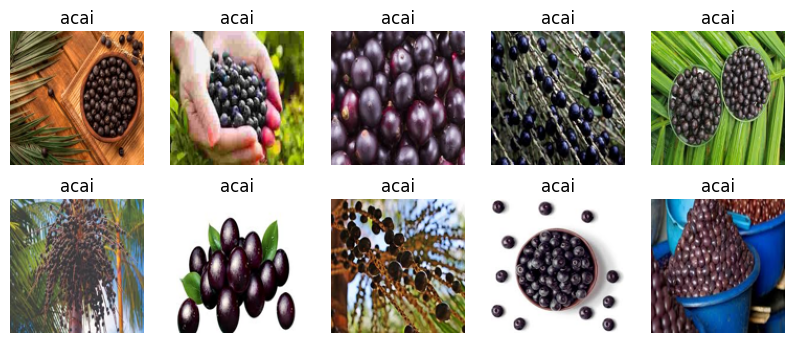

In [37]:
# Define dataset paths
train_dir = "FruitinAmazon/FruitinAmazon/train/"
test_dir = "FruitinAmazon/FruitinAmazon/test/"

class_names = sorted(os.listdir(train_dir))
class_map = {name: i for i, name in enumerate(class_names)}
num_classes = len(class_names)

# Define image size
img_height, img_width = 128, 128

# Function to load images and integer labels using PIL
def load_images_from_folder(folder, class_map):
    images = []
    labels = []

    for class_name in class_map.keys():
        class_path = os.path.join(folder, class_name)

        if not os.path.exists(class_path):
            continue  # Skip missing class in test set

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("RGB")
            img = img.resize((img_width, img_height))
            img = np.array(img, dtype=np.float32)
            images.append(img)
            labels.append(label)

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

# Load train/test arrays for quick visualization and optional direct prediction
x_train, y_train = load_images_from_folder(train_dir, class_map)
x_test, y_test = load_images_from_folder(test_dir, class_map)

print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].astype(np.uint8))
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()

In [38]:
print("All classes:", class_names)

All classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [39]:
from logging import exception
def find_corrupt_images(folder):
  image_removed = False
  class_names = sorted(os.listdir(folder)) # Sorted class names
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
      class_path = os.path.join(folder, class_name)
      label = class_map[class_name]
      for filename in os.listdir(class_path):
          img_path = os.path.join(class_path, filename)
          # Load image using PIL
          try:
            img = Image.open(img_path)
            img.verify()
          except Exception:
            image_removed = True
            print(f"Corrupt image found: {img_path}")
            os.remove(img_path)
  return image_removed

if find_corrupt_images(train_dir):
  print("corrupt images found and removed")
else:
  print("no corrupt images found")

no corrupt images found


Task 2: Loading and Preprocessing Image Data in keras:

In [40]:
batch_size = 16
validation_split = 0.2
AUTOTUNE = tf.data.AUTOTUNE

In [41]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [42]:
# Create training dataset (keep raw 0-255 pixels; model will rescale)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=1234
)

class_names_train = train_ds.class_names
num_classes = len(class_names_train)

# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=1234
)

# Create test dataset for consistent evaluation
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)
class_names_test = test_ds.class_names

# Performance pipeline
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds)}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Number of training batches: 5
Number of validation batches: 2
Number of test batches: 2


Task 3 - Implement a CNN with:

In [43]:
from tensorflow.keras.applications import MobileNetV2

# Build a transfer-learning model (better for small datasets)
try:
    base_model = MobileNetV2(
        input_shape=(img_height, img_width, 3),
        include_top=False,
        weights='imagenet'
    )
    print("Loaded MobileNetV2 with ImageNet weights.")
except Exception as e:
    print(f"ImageNet weights unavailable ({e}). Falling back to random initialization.")
    base_model = MobileNetV2(
        input_shape=(img_height, img_width, 3),
        include_top=False,
        weights=None
    )

base_model.trainable = False

inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
# MobileNetV2 expects inputs in [-1, 1]
x = tf.keras.layers.Rescaling(scale=1./127.5, offset=-1)(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.35)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Loaded MobileNetV2 with ImageNet weights.


Model: "functional_101"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Task 4: Compile and Train the Model

In [44]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for training
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 413ms/step - accuracy: 0.2083 - loss: 2.6163 - val_accuracy: 0.3333 - val_loss: 1.6968 - learning_rate: 3.0000e-04
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3194 - loss: 1.8385 - val_accuracy: 0.2222 - val_loss: 1.8074 - learning_rate: 3.0000e-04
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4028 - loss: 1.5547 - val_accuracy: 0.1111 - val_loss: 1.9272 - learning_rate: 3.0000e-04
Epoch 4/40
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5156 - loss: 1.2795
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5000 - loss: 1.3254 - val_accuracy: 0.1667 - val_loss: 1.8588 - learning_rate: 3.0000e-04
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5139 - loss: 1.3058 - val_accuracy: 0.2778 - val_loss: 1.7993 - learning_rate: 1.5000e-04
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5833 - loss: 1.1096 - v

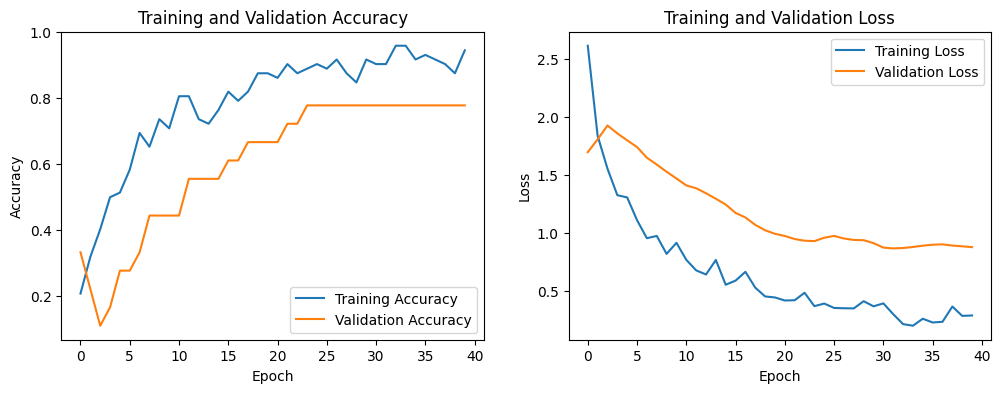

In [45]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Task 5: Evaluate the Model

In [46]:
# Load the best model saved by ModelCheckpoint
loaded_model = tf.keras.models.load_model('best_model.keras')

# Evaluate on test dataset (integer labels, same preprocessing path)
loss, accuracy = loaded_model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.8333 - loss: 0.5621
Test Loss: 0.5621
Test Accuracy: 0.8333


In [47]:
for x, y in train_ds.take(1):
    print(y[:5])

for x, y in val_ds.take(1):
    print(y[:5])


tf.Tensor([2 4 3 0 3], shape=(5,), dtype=int32)
tf.Tensor([4 4 4 5 5], shape=(5,), dtype=int32)


Task 6: Save and Load the Model

In [48]:
# Save the model in the recommended Keras format
model.save('final_fruit_classifier_model.keras')

loaded_model_reloaded = tf.keras.models.load_model('final_fruit_classifier_model.keras')
print("Model reloaded successfully.")

Model reloaded successfully.


Task 7: Predictions and Classification Report

In [49]:
from sklearn.metrics import classification_report

# Collect true labels from the test dataset
true_labels = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# Predict over test dataset
predictions = loaded_model.predict(test_ds, verbose=1)
predicted_labels = np.argmax(predictions, axis=1)

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names_test, zero_division=0))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step
Classification Report:
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.71      1.00      0.83         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.71      1.00      0.83         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.83        30
   macro avg       0.87      0.83      0.82        30
weighted avg       0.87      0.83      0.82        30

